Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.42MB/s]


Epoch [1/10] Loss: 0.0585
Epoch [2/10] Loss: 0.0265
Epoch [3/10] Loss: 0.0230
Epoch [4/10] Loss: 0.0214
Epoch [5/10] Loss: 0.0201
Epoch [6/10] Loss: 0.0191
Epoch [7/10] Loss: 0.0184
Epoch [8/10] Loss: 0.0179
Epoch [9/10] Loss: 0.0177
Epoch [10/10] Loss: 0.0173
Model saved.


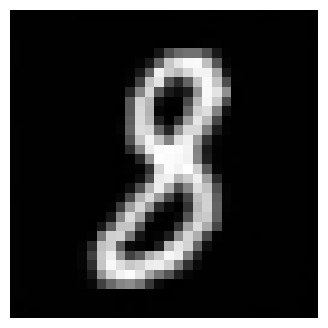

In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from diffusers import UNet2DModel, DDPMScheduler

# ==========================
# Device
# ==========================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

# ==========================
# Dataset
# ==========================

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

# ==========================
# Diffusion Model
# ==========================

model = UNet2DModel(
    sample_size=32,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,

    block_out_channels=(32, 64, 64),

    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),

    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
).to(device)

# ==========================
# Noise Scheduler
# ==========================

noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000
)

# ==========================
# Optimizer
# ==========================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

# ==========================
# Training
# ==========================

epochs = 10

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        noise = torch.randn_like(images)

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (images.shape[0],),
            device=device
        ).long()

        noisy_images = noise_scheduler.add_noise(
            images,
            noise,
            timesteps
        )

        noise_pred = model(
            noisy_images,
            timesteps
        ).sample

        loss = F.mse_loss(
            noise_pred,
            noise
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.4f}"
    )

# ==========================
# Save Model
# ==========================

model.save_pretrained("./mnist_diffusion")

print("Model saved.")

# ==========================
# Generate Samples
# ==========================

model.eval()

sample = torch.randn(
    (1, 1, 32, 32),
    device=device
)

noise_scheduler.set_timesteps(1000)

for t in noise_scheduler.timesteps:

    with torch.no_grad():

        residual = model(
            sample,
            t
        ).sample

    sample = noise_scheduler.step(
        residual,
        t,
        sample
    ).prev_sample

# ==========================
# Convert Back To Image
# ==========================

sample = sample.cpu().squeeze()

sample = (sample + 1) / 2
sample = sample.clamp(0, 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.imshow(sample, cmap="gray")
plt.axis("off")
plt.show()